# Multivariable Linear Regression

Here we will implement a linear regression model, but instead of only using one predictor, we will use several. Then train the model and be able to predict one output value.

Since we are now using multiple features "x", x will be as follows: $$X =[x_1, x_2, x_3, ... x_n]$$ meaning we will also have differente w values: $$W =[w_1, w_2, w_3, ... w_n]$$

To compute W x X we will make use of the dot product, using `np.dot(X, W)`

This means that we will implement linear regression just as we were, but taking into consideration that now we have vectors X and w, instead of them being single values.

In [117]:
#Start by importing the used libraries:

import copy, math
import numpy as np
import matplotlib.pyplot as plt

In [118]:
#Notice how X is now a 3x4 matrix. This means our data now has 4 features n and 3 rows m
X_train = np.array([[2104, 5, 1, 45], [1416, 3, 2, 40], [852, 2, 1, 35]])
y_train = np.array([460, 232, 178])

#Initialize w and b:
b_init = 785.1811367994083
w_init = np.array([ 0.39133535, 18.75376741, -53.36032453, -26.42131618])

In [119]:
#We can do this list slicing because we use numpy. This means: Give me only the 1st value of all rows.
size = X_train[:,0]
#We do the same with all features:
bedrooms = X_train[:,1]
floors = X_train[:,2]
age = X_train[:,3]

#Put them in a list so we can plot after:
feature_names = [size, bedrooms, floors, age]

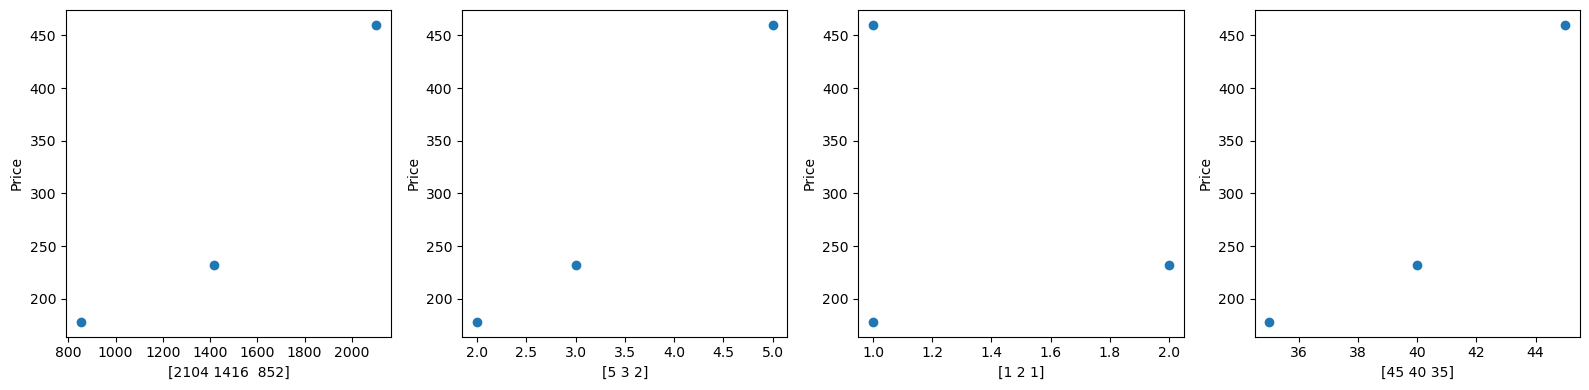

In [120]:
#Graph all features vs price (prediction) to visualize our data:
n = X_train.shape[1]

fig, ax = plt.subplots(1, n, figsize=(16, 4))

for i in range(n):
    ax[i].scatter(X_train[:, i], y_train)
    ax[i].set_xlabel(feature_names[i])
    ax[i].set_ylabel("Price")

plt.tight_layout()
plt.show()

In [121]:
# This function is the similar to f_wb = wx + b. Here I am making a function just to calculate f_wb, using numpy's dot product instead of a for loop.
# Reason is that numpy's dot product is waaay faster!

def predict(x, w, b):
    p = np.dot(x, w) + b
    return p
    

## Cost Function

The cost function stays the same, we just need to remember that now $w$ and $x^(i)$ are vectors, rather than scalars:
$$J(\mathbf{w},b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})^2$$

and:
$$ f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = \mathbf{w} \cdot \mathbf{x}^{(i)} + b $$ 

In [134]:
# We implement the cost function. Notice the X argument in the function is now a capital X (indicating its a vector).
def compute_cost(X, y, w, b):
    m = X.shape[0]
    total_cost = 0
    for i in range(m):
        total_cost += (predict(X[i], w, b) - y[i])**2
    total_cost = total_cost / (2 * m)

    return total_cost
    

## Gradient Descent

Recall the formulas:

$$\begin{align*} \text{repeat}&\text{ until convergence:} \; \lbrace \newline\;
& w_j = w_j -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial w_j}\; & \text{for j = 0..n-1}\newline
&b\ \ = b -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial b}  \newline \rbrace
\end{align*}$$

where, n is the number of features, parameters $w_j$,  $b$, are updated simultaneously and where  

$$
\begin{align}
\frac{\partial J(\mathbf{w},b)}{\partial w_j}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})x_{j}^{(i)}  \\
\frac{\partial J(\mathbf{w},b)}{\partial b}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})
\end{align}
$$

In [135]:
def compute_gradient(X, y, w, b):
    m,n = X.shape           #(number of examples, number of features)
    dj_dw = np.zeros((n,))
    dj_db = 0.

    for i in range(m):                             
        err = (np.dot(X[i], w) + b) - y[i]   
        for j in range(n):                         
            dj_dw[j] = dj_dw[j] + err * X[i, j]    
        dj_db = dj_db + err                        
    dj_dw = dj_dw / m                                
    dj_db = dj_db / m                                
        
    return dj_db, dj_dw

## Gradient Descent

We can now implement gradient descent

In [151]:
alpha = 0.001
num_iters = 1000

def gradient_descent(X, y, w_in, b_in, alpha, num_iters):
    w = copy.deepcopy(w_in)  #avoid modifying global w within function
    b = b_in
    J_history = []
    
    for i in range(num_iters):

        # Calculate the gradient and update the parameters
        dj_db,dj_dw = compute_gradient(X, y, w, b)   

        # Update Parameters using w, b, alpha and gradient
        w = w - alpha * dj_dw               
        b = b - alpha * dj_db               
      
        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion 
            J_history.append(compute_cost(X, y, w, b))

        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters / 10) == 0:
            print(f"Iteration {i:4d}: Cost {J_history[-1]:8.2f}   ")
        
    return w, b, J_history #return final w,b and J history for graphing

In [157]:
# Inicializar parámetros en cero para el entrenamiento
initial_w = np.zeros_like(w_init)
initial_b = 0.0

# Configuraciones del descenso del gradiente
iterations = 1000
alpha = 0.0000006  # Una tasa de aprendizaje pequeña para evitar que el costo explote

# Ejecutar el descenso del gradiente
w_final, b_final, J_history = gradient_descent(X_train, y_train, initial_w, initial_b,
                                                    alpha, iterations)

print(f"\nb final encontrado por el algoritmo: {b_final:0.2f}")
print(f"w final encontrado por el algoritmo: {w_final}")

Iteration    0: Cost  9828.53   
Iteration  100: Cost   695.77   
Iteration  200: Cost   694.49   
Iteration  300: Cost   693.23   
Iteration  400: Cost   691.97   
Iteration  500: Cost   690.73   
Iteration  600: Cost   689.51   
Iteration  700: Cost   688.29   
Iteration  800: Cost   687.09   
Iteration  900: Cost   685.90   

b final encontrado por el algoritmo: -0.00
w final encontrado por el algoritmo: [ 0.20431602  0.00440328 -0.01351183 -0.07968033]


# Predict a custom value

We successfully trained our model. now we can input new values and make a prediction!


In [158]:
custom_house = np.array([852, 2, 1, 35])

# Predict the price
predicted_price = predict(custom_house, w_final, b_final)

print(f"Predicted house price: ${predicted_price:.2f}k")

Predicted house price: $171.28k


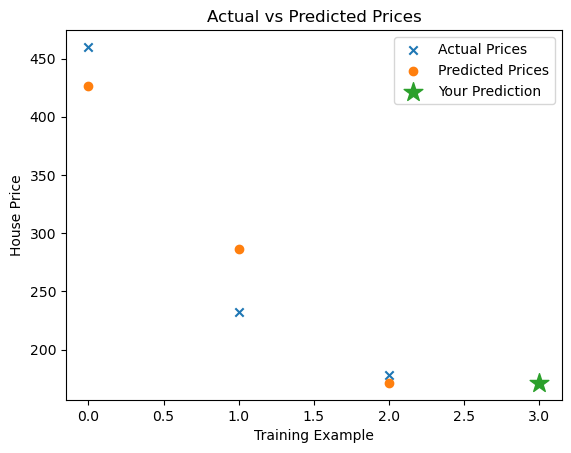

In [159]:
# Predict all training examples
predictions = np.dot(X_train, w_final) + b_final

# Predict your custom house price
custom_prediction = np.dot(custom_house, w_final) + b_final

# Graph
plt.scatter(range(len(y_train)), y_train, marker='x', label='Actual Prices')
plt.scatter(range(len(predictions)), predictions, marker='o', label='Predicted Prices')

# Plot your custom prediction separately
plt.scatter(len(y_train), custom_prediction, marker='*', s=200, label='Your Prediction')

plt.xlabel("Training Example")
plt.ylabel("House Price")
plt.title("Actual vs Predicted Prices")
plt.legend()
plt.show()